## Imports and Setup

We created specific utils file for each part of the project.

In [1]:
# -- Third-party ----------------------------------------------------------------
import sys
import os

import pandas as pd
from dotenv import load_dotenv

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold

from transformers.utils import logging as transformers_logging

from langchain_openai import AzureChatOpenAI

# -- Project utils ---------------------------------------------------------------
sys.path.insert(0, os.path.abspath("../src"))
from text_mining_utils import (
    LABEL_MAP,
    RANDOM_STATE,
    EMBEDDING_CACHE_DIR,
    Word2VecVectorizer,
    preprocess_pipeline,
    plot_class_distribution,
    plot_tweet_length_distribution,
    plot_wordclouds,
    plot_top_tokens,
    show_preprocessing_examples,
    plot_model_confusion_matrix,
    detect_transformer_device,
    run_transformer_encoder_experiment,
    run_classical_text_experiment,
    run_finetune_encoder_cv_experiment,
    run_decoder_cv_experiment,
    build_model_comparison_df,
    plot_family_validation_f1,
    plot_family_cv_f1,
    style_model_comparison_table,
)

# -- Configuration ---------------------------------------------------------------
load_dotenv()
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
transformers_logging.set_verbosity_error()

AZURE_MODEL_NAME = os.getenv("AZURE_MODEL_NAME", "")
AZURE_ENDPOINT = os.getenv("AZURE_ENDPOINT", "")
AZURE_KEY = os.getenv("AZURE_KEY", "")
AZURE_API_VERSION = os.getenv("AZURE_API_VERSION", "")

# Load training and test data
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

## Data Exploration


In [2]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9543 non-null   str  
 1   label   9543 non-null   int64
dtypes: int64(1), str(1)
memory usage: 954.7 KB


In [3]:
(train_df["label"].value_counts(normalize=True).sort_index() * 100).round(2)

label
0    15.11
1    20.15
2    64.74
Name: proportion, dtype: float64

In [4]:
train_df.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


### Class Distribution

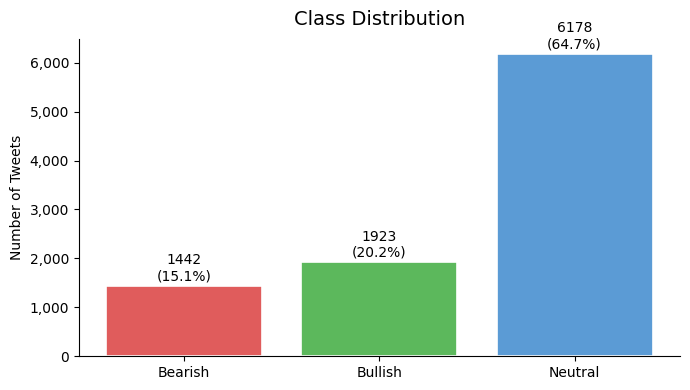

In [5]:
plot_class_distribution(train_df, label_col="label")

The majority of the dataset has as label "Neutral", showing great class imbalacement.

### Tweet Length Distribution

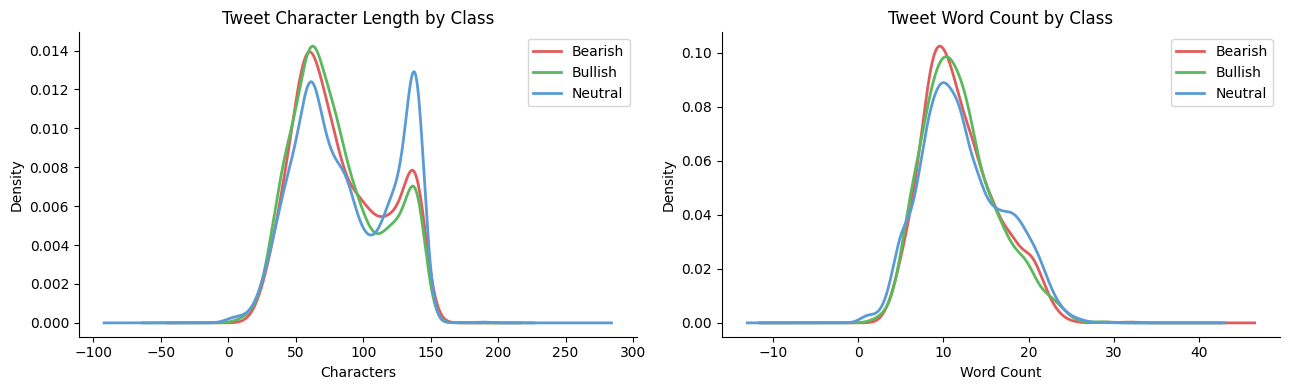

In [6]:
plot_tweet_length_distribution(train_df, text_col="text", label_col="label")

In [7]:
# Summary stats per class
train_df["char_len"]  = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df.groupby("label")[["char_len", "word_count"]].describe().round(1)

char_len                                             word_count        \
         count  mean   std   min   25%   50%    75%    max      count  mean   
label                                                                         
0       1442.0  83.3  33.0  20.0  57.2  75.5  110.8  151.0     1442.0  12.0   
1       1923.0  80.4  32.3   9.0  57.0  74.0  103.0  154.0     1923.0  11.9   
2       6178.0  88.1  36.2   2.0  59.0  82.0  125.0  190.0     6178.0  12.3   

                                        
       std  min  25%   50%   75%   max  
label                                   
0      4.3  3.0  9.0  11.0  15.0  32.0  
1      4.3  2.0  9.0  11.0  14.0  29.0  
2      4.8  1.0  9.0  12.0  16.0  29.0

We conclude that does not exist a difference between the tweet sizes and the label.

### Word Clouds per Class

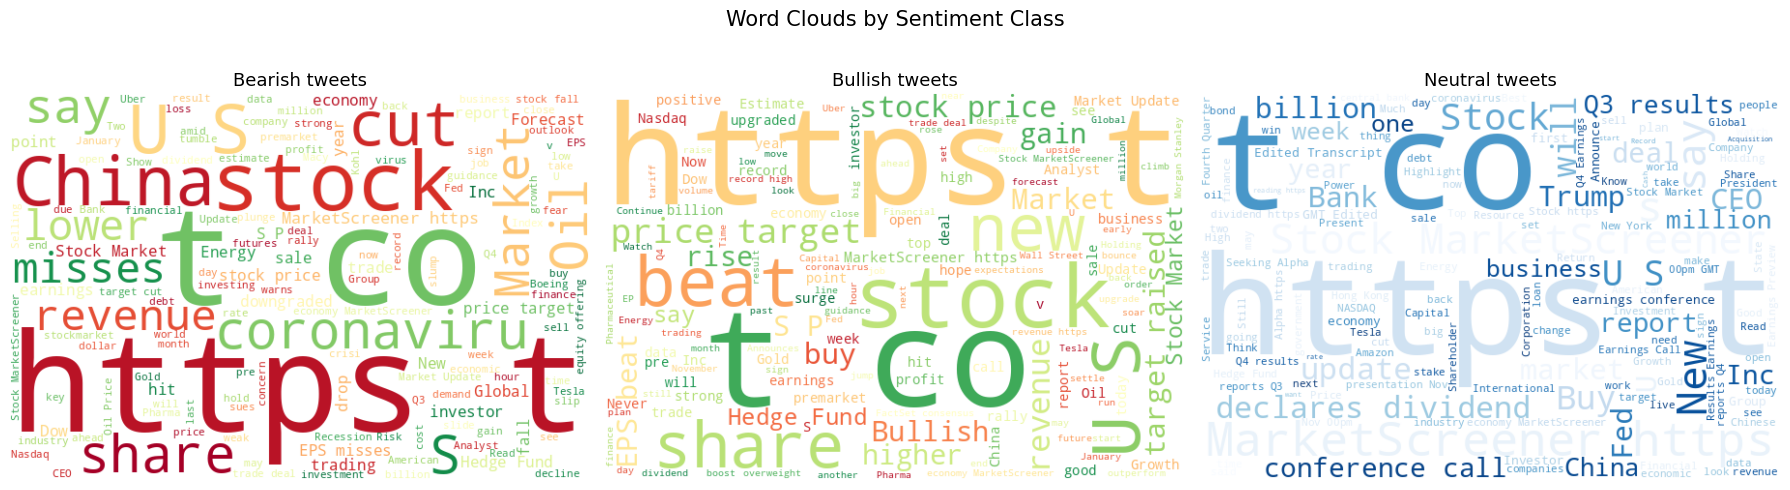

In [8]:
plot_wordclouds(train_df, text_col="text", label_col="label")

From the word clouds before preprocessing, frequent tokens are still dominated by noisy market syntax (tickers, short boilerplate fragments, and repeated symbols). This motivates the use of stronger normalization before feature extraction.

### Top Tokens per Class (before preprocessing)

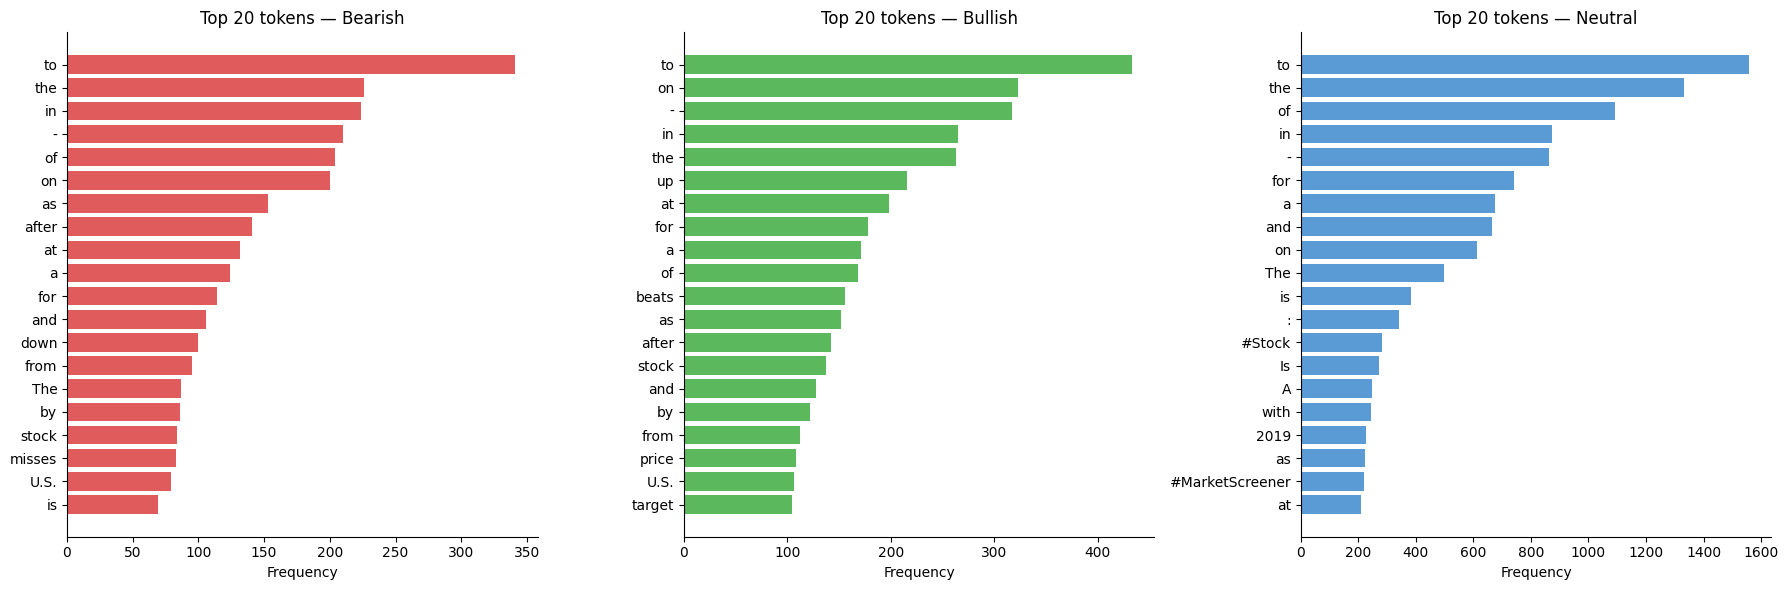

In [9]:
plot_top_tokens(train_df, text_col="text", label_col="label", n=20)

## Data Preprocessing

The preprocessing pipeline is mode-based with two clear routes:

### Classical Mode (for TF-IDF and Word2Vec)
- Regex noise removal: URLs, mentions, cashtags, HTML entities, non-ASCII
- Tokenization: NLTK TweetTokenizer
- Stop word removal
- POS-aware lemmatization
- Result: Clean, normalized tokens ready for vectorization

### Transformer Mode (for BERT-style encoders)
- Lightweight normalization preserving structure
- Placeholder tokens: `[URL]`, `[USER]`, `[CASHTAG]`, `[HASHTAG]`, `[RT]`
- Minimal filtering to preserve semantic context
- Result: Text ready for transformer tokenizer

Each mode is optimized for its respective feature extraction pipeline.

### Before / After Examples - Classical Mode

In [10]:
examples_df = show_preprocessing_examples(
    train_df, text_col="text", n=10, pipeline_fn=preprocess_pipeline
)
examples_df

,original,preprocessed
0,Nokia stock price target raised to $6.00 from ...,nokia stock price target raise mkm partner
1,Russia backs OPEC+ oil output cuts,russia back opec oil output cut
2,Many workers don't have access to retirement s...,many worker access retirement saving program e...
3,About 200 Google employees demonstrated outsid...,google employee demonstrate outside company sa...
4,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...,idg energy investment voluntary announcement i...
5,Vans parent VF Corp. says 60% of China stores ...,van parent vf corp say china store close coron...
6,AU Optronics reports Q4 results,au optronics report q result
7,$KZR Kezar Life Sciences Highlights Therapeuti...,kezar life science highlight therapeutic poten...
8,U.S. Oil Inventories Rise More Than Expected #...,u oil inventory rise expect wti stock marketsc...
9,A Big Step Forward For the Treatment of ALS,big step forward treatment al


### Before / After Examples - Transformer Mode

In [11]:
examples_df = show_preprocessing_examples(
    train_df, text_col="text", n=10, pipeline_fn=preprocess_pipeline, mode = "transformer"
)
examples_df

,original,preprocessed
0,Nokia stock price target raised to $6.00 from ...,Nokia stock price target raised to $6.00 from ...
1,Russia backs OPEC+ oil output cuts,Russia backs OPEC+ oil output cuts
2,Many workers don't have access to retirement s...,Many workers don't have access to retirement s...
3,About 200 Google employees demonstrated outsid...,About 200 Google employees demonstrated outsid...
4,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...
5,Vans parent VF Corp. says 60% of China stores ...,Vans parent VF Corp. says 60% of China stores ...
6,AU Optronics reports Q4 results,AU Optronics reports Q4 results
7,$KZR Kezar Life Sciences Highlights Therapeuti...,[CASHTAG] Kezar Life Sciences Highlights Thera...
8,U.S. Oil Inventories Rise More Than Expected #...,U.S. Oil Inventories Rise More Than Expected [...
9,A Big Step Forward For the Treatment of ALS,A Big Step Forward For the Treatment of ALS


### Top Tokens After Preprocessing

Compare the top tokens before and after — confirms noise removal and stop word filtering worked.

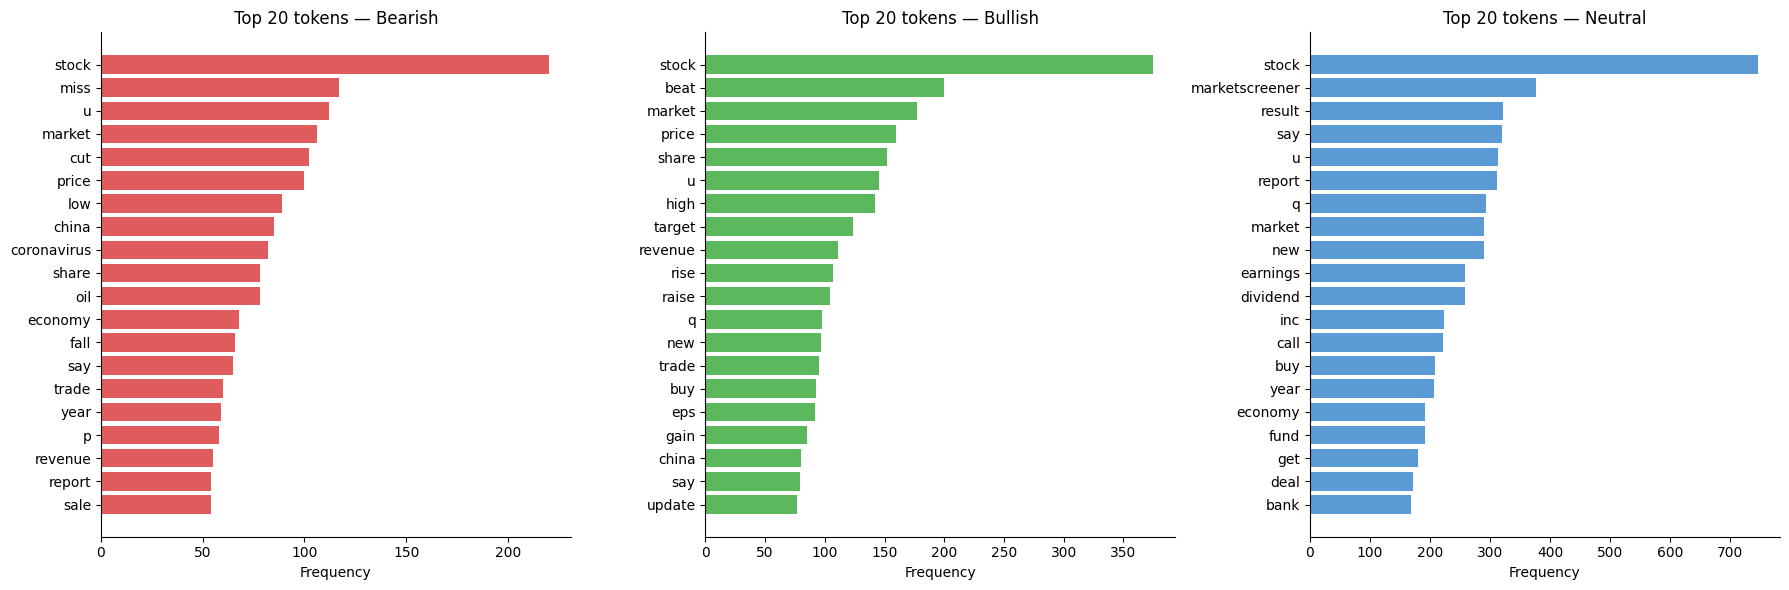

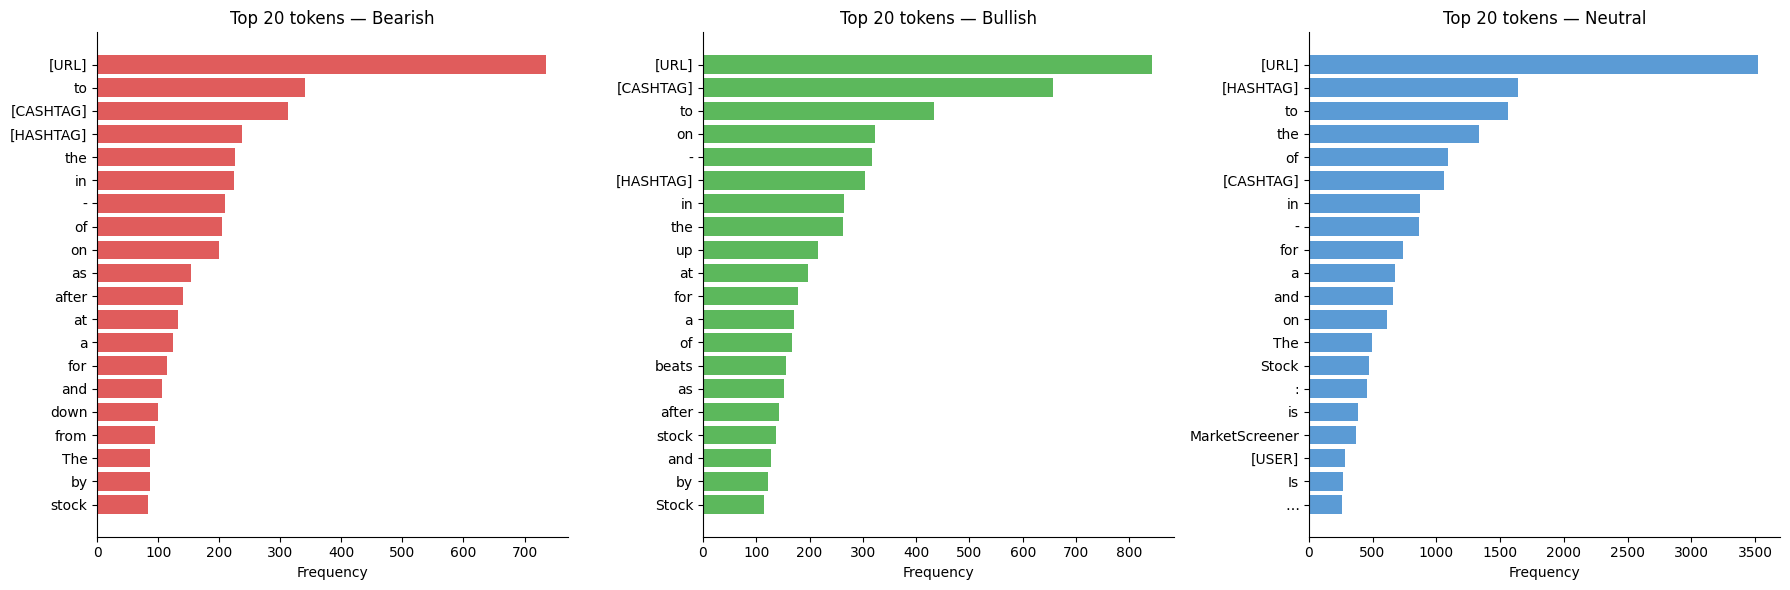

In [12]:
# Build a temporary df with preprocessed text for the full train set (for visualization only)
train_df["text_classical"] = preprocess_pipeline(train_df["text"])
train_df["text_transformer"] = preprocess_pipeline(train_df["text"], mode="transformer")

plot_top_tokens(train_df, text_col="text_classical", label_col="label", n=20)
plot_top_tokens(train_df, text_col="text_transformer", label_col="label", n=20)

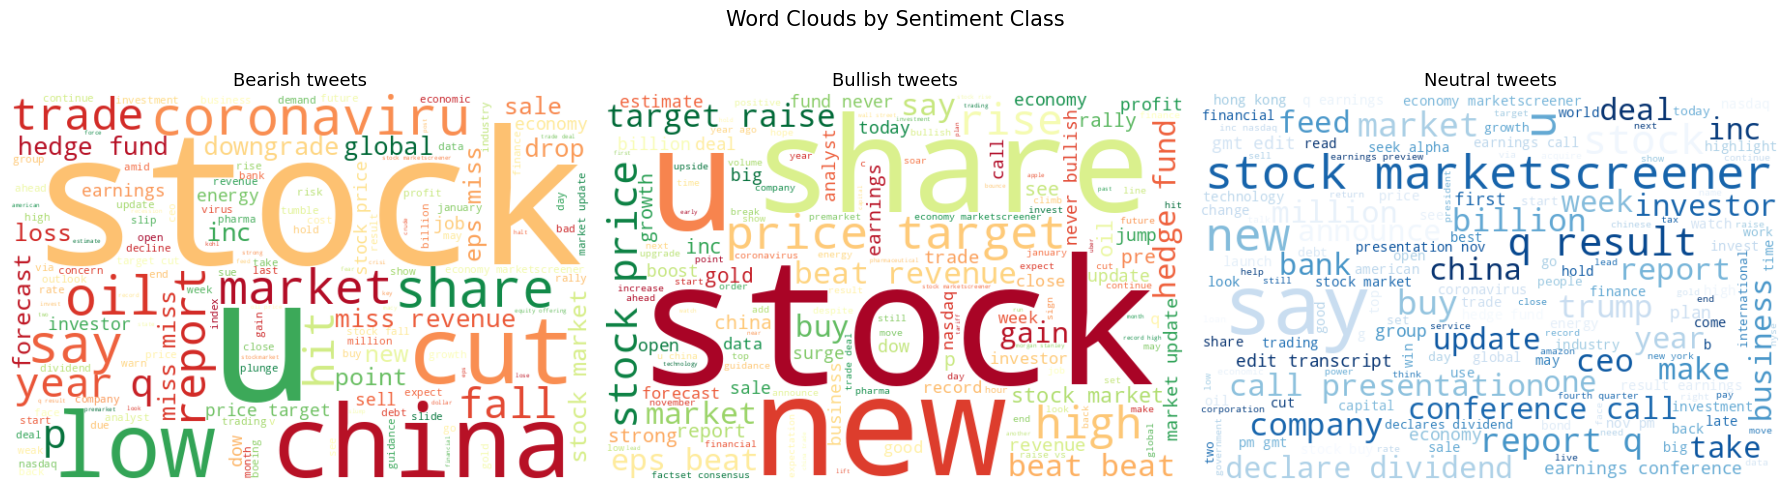

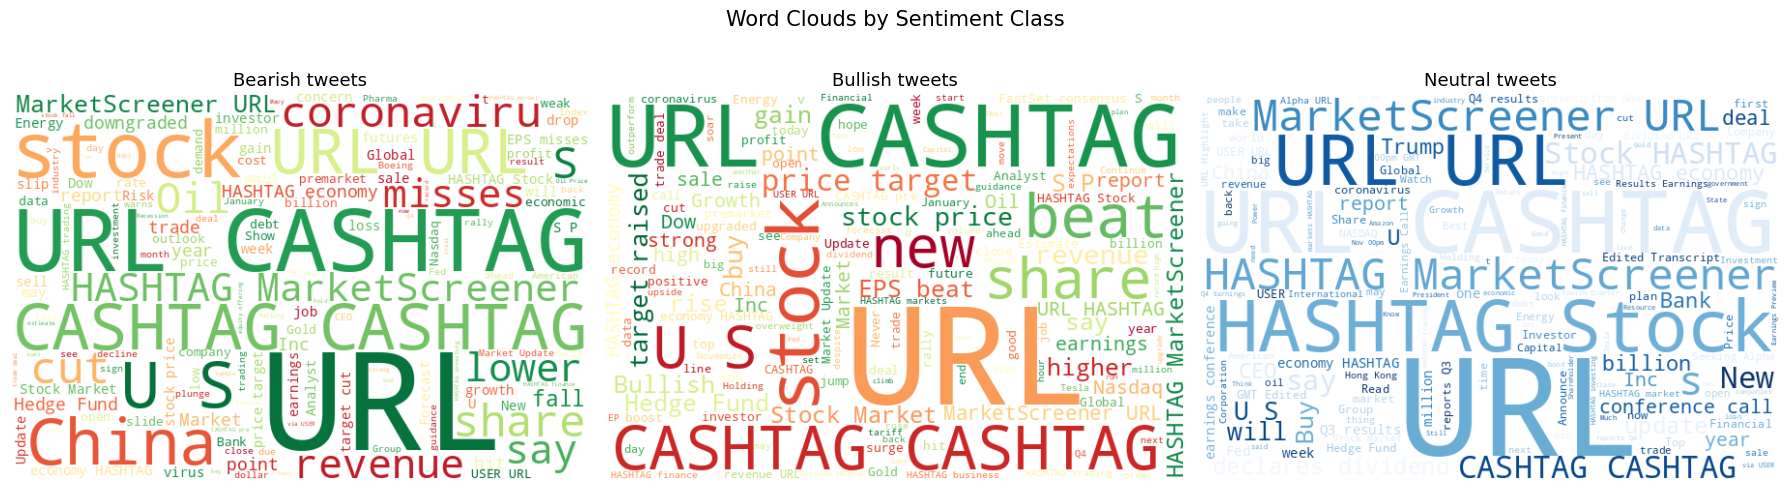

In [13]:
# Word clouds after preprocessing
plot_wordclouds(train_df, text_col="text_classical", label_col="label")
plot_wordclouds(train_df, text_col="text_transformer", label_col="label")

Preprocessing results are consistent with the intended behavior of both routes:
- Classical mode highlights cleaner semantic tokens useful for traditional vectorizers.
- Transformer mode preserves contextual cues through placeholder tokens such as `[URL]`, `[USER]`, and `[CASHTAG]`, which can help downstream transformer tokenizers retain structure.

# Data Split

### Using Cross-Validation for Robust Evaluation

We use **stratified 5-fold cross-validation** on the entire training dataset. This approach:
- Maximizes data utilization (no separate validation set)
- Provides robust performance estimates via multiple fold runs
- Preserves class distribution (important given Neutral >> Bullish/Bearish imbalance)

We prepare text in two modes for different model families:
- `classical`: lemmatized text for TF-IDF vectorization
- `transformer`: lightweight normalization for BERT-style encoders

### Preprocess Text in Both Modes

Prepare the full training dataset in both preprocessing modes for CV-based experiments.

In [14]:
# Prepare full training dataset in both modes for CV experiments
X_classical = preprocess_pipeline(train_df["text"], mode="classical")
X_transformer = preprocess_pipeline(train_df["text"], mode="transformer")
y_labels = train_df["label"]

print(f"Full training dataset: {len(y_labels):,} samples")
print(f"Class distribution:")
for label_id in sorted(train_df["label"].unique()):
    count = (y_labels == label_id).sum()
    pct = count / len(y_labels) * 100
    print(f"  {LABEL_MAP[label_id]}: {count:,} ({pct:.1f}%)")

Full training dataset: 9,543 samples
Class distribution:
  Bearish: 1,442 (15.1%)
  Bullish: 1,923 (20.2%)
  Neutral: 6,178 (64.7%)


In [15]:
pd.DataFrame(
    {
        "raw": train_df["text"].head(3).to_list(),
        "classical": X_classical.head(3).to_list(),
        "transformer": X_transformer.head(3).to_list(),
        "label": y_labels.head(3).to_list(),
    }
)

,raw,classical,transformer,label
0,$BYND - JPMorgan reels in expectations on Beyo...,jpmorgan reel expectation beyond meat,[CASHTAG] - JPMorgan reels in expectations on ...,0
1,$CCL $RCL - Nomura points to bookings weakness...,nomura point booking weakness carnival royal c...,[CASHTAG] [CASHTAG] - Nomura points to booking...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",cemex cut credit suisse j p morgan weak buildi...,"[CASHTAG] - Cemex cut at Credit Suisse, J.P. M...",0


In [16]:
CV_FOLDS = 5
cv_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Feature Engineering and Classification Models

This section combines feature preparation and model evaluation under a single modeling workflow.

### Transformer Encoder Features

Following the same idea used in Lab 4, we convert each tweet into a dense vector with a Hugging Face encoder and then feed those vectors into a simple classifier.


In [17]:
TRANSFORMER_ENCODERS = {
    "DistilBERT": "distilbert-base-uncased",
    "Twitter RoBERTa": "cardiffnlp/twitter-roberta-base",
}

BATCH_SIZE = 16
MAX_LENGTH = 96

device, device_name = detect_transformer_device()

print(f"Using device: {device_name}")
print(f"Dataset size: {len(X_transformer):,} samples for CV")

Using device: cuda
Dataset size: 9,543 samples for CV


### Classification Models

This section evaluates **three feature extraction approaches** using **5-fold stratified cross-validation**:

### Classical Approach 1
- **Vectorization**: n-gram text vectorization with sublinear scaling and min_df filtering
- **Classifiers**: Logistic Regression, Random Forest, SVM (RBF), Gradient Boosting, MLP
- **Advantage**: Interpretable, fast, captures term importance

### Classical Approach 2: Word2Vec
- **Vectorization**: Pretrained word embeddings, mean pooling to document vectors
- **Classifiers**: Same 5 classifiers as Classical Approach 1
- **Advantage**: Captures semantic relationships, handles OOV words gracefully

### Transformer Encoders
- **Models**: DistilBERT, Twitter RoBERTa
- **Vectorization**: Dense embeddings from [CLS] token
- **Classifier**: Classical classifier on frozen embeddings
- **Advantage**: State-of-the-art contextual representations

**Class Imbalance Handling**: 
- Uses `class_weight="balanced"` to inversely weight rare classes
- Combined with stratified 5-fold CV for robust evaluation
- No separate train/val split; full data utilization via CV

**Metrics Reported (Macro + Accuracy):**
- **Precision-macro**: average class purity, giving equal weight to each label
- **Recall-macro**: average ability to recover each class, including minority labels
- **F1-macro**: harmonic balance of precision and recall across classes
- **Accuracy**: overall fraction of correct predictions (can be inflated by majority class)

Because this dataset is imbalanced (Neutral >> Bullish/Bearish), **macro metrics are primary** for model selection, while accuracy is used as supporting context.

In [18]:
CLASSIFIERS = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "SVM (RBF)": SVC(
        kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(256, 128), max_iter=300, early_stopping=True, random_state=RANDOM_STATE
    ),
}

# Classical experiments + Classifiers
classical_runs = {}
classical_metrics = []

print("Training classical models (n-gram vectorization)...")
for clf_name, clf in CLASSIFIERS.items():
    experiment_name = f"Classical + {clf_name}"
    result = run_classical_text_experiment(
        experiment_name=experiment_name,
        vectorizer=TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=40000,
            sublinear_tf=True,
        ),
        classifier=clf,
        X_train_text=X_classical,
        y_train_labels=y_labels,
        cv=cv_splitter,
        verbose=True,
    )
    classical_runs[experiment_name] = result
    classical_metrics.append(result["metrics"])

classical_results_df = (
    pd.DataFrame(classical_metrics)
    .sort_values("cv_f1_macro_mean", ascending=False)
    .reset_index(drop=True)
)

print("\nClassical models complete")
display(classical_results_df.head(5))

Training classical models (n-gram vectorization)...
Classical + Logistic Regression | Precision: 0.7151 | Recall: 0.7307 | F1: 0.7224 | Accuracy: 0.7908
Classical + Random Forest | Precision: 0.7171 | Recall: 0.7107 | F1: 0.7131 | Accuracy: 0.7877
Classical + SVM (RBF) | Precision: 0.762 | Recall: 0.6867 | F1: 0.7156 | Accuracy: 0.8043
Classical + Gradient Boosting | Precision: 0.786 | Recall: 0.5826 | F1: 0.6308 | Accuracy: 0.7658
Classical + MLP | Precision: 0.7415 | Recall: 0.6781 | F1: 0.703 | Accuracy: 0.7933

Classical models complete


,model,cv_precision_macro_mean,cv_precision_macro_std,cv_recall_macro_mean,cv_recall_macro_std,cv_f1_macro_mean,cv_f1_macro_std,cv_accuracy_mean,cv_accuracy_std,accuracy,precision,recall,f1_macro
0,Classical + Logistic Regression,0.7151,0.0067,0.7307,0.0098,0.7224,0.0080,0.7908,0.0066,0.7908,0.7151,0.7307,0.7224
1,Classical + SVM (RBF),0.7620,0.0100,0.6867,0.0118,0.7156,0.0113,0.8043,0.0073,0.8043,0.7620,0.6867,0.7156
2,Classical + Random Forest,0.7171,0.0056,0.7107,0.0088,0.7131,0.0073,0.7877,0.0050,0.7877,0.7171,0.7107,0.7131
3,Classical + MLP,0.7415,0.0105,0.6781,0.0113,0.7030,0.0099,0.7933,0.0069,0.7933,0.7415,0.6781,0.7030
4,Classical + Gradient Boosting,0.7860,0.0183,0.5826,0.0042,0.6308,0.0070,0.7658,0.0034,0.7658,0.7860,0.5826,0.6308


In [19]:
# Classical experiments: Word2Vec + Classifiers
print("Training Word2Vec models...")

for clf_name, clf in CLASSIFIERS.items():
    experiment_name = f"Word2Vec + {clf_name}"
    result = run_classical_text_experiment(
        experiment_name=experiment_name,
        vectorizer=Word2VecVectorizer(size=100, window=5, min_count=2),
        classifier=clf,
        X_train_text=X_classical,
        y_train_labels=y_labels,
        cv=cv_splitter,
        verbose=True,
    )
    classical_runs[experiment_name] = result
    classical_metrics.append(result["metrics"])

classical_results_df = (
    pd.DataFrame(classical_metrics)
    .sort_values("cv_f1_macro_mean", ascending=False)
    .reset_index(drop=True)
)

print("\nWord2Vec models complete")
display(classical_results_df.head(10))

Training Word2Vec models...
Word2Vec + Logistic Regression | Precision: 0.441 | Recall: 0.4572 | F1: 0.4425 | Accuracy: 0.5437
Word2Vec + Random Forest | Precision: 0.5276 | Recall: 0.5026 | F1: 0.5105 | Accuracy: 0.6677
Word2Vec + SVM (RBF) | Precision: 0.425 | Recall: 0.4409 | F1: 0.4062 | Accuracy: 0.4608
Word2Vec + Gradient Boosting | Precision: 0.5605 | Recall: 0.4428 | F1: 0.4486 | Accuracy: 0.6845
Word2Vec + MLP | Precision: 0.6458 | Recall: 0.3878 | F1: 0.3635 | Accuracy: 0.6677

Word2Vec models complete


,model,cv_precision_macro_mean,cv_precision_macro_std,cv_recall_macro_mean,cv_recall_macro_std,cv_f1_macro_mean,cv_f1_macro_std,cv_accuracy_mean,cv_accuracy_std,accuracy,precision,recall,f1_macro
0,Classical + Logistic Regression,0.7151,0.0067,0.7307,0.0098,0.7224,0.0080,0.7908,0.0066,0.7908,0.7151,0.7307,0.7224
1,Classical + SVM (RBF),0.7620,0.0100,0.6867,0.0118,0.7156,0.0113,0.8043,0.0073,0.8043,0.7620,0.6867,0.7156
2,Classical + Random Forest,0.7171,0.0056,0.7107,0.0088,0.7131,0.0073,0.7877,0.0050,0.7877,0.7171,0.7107,0.7131
3,Classical + MLP,0.7415,0.0105,0.6781,0.0113,0.7030,0.0099,0.7933,0.0069,0.7933,0.7415,0.6781,0.7030
4,Classical + Gradient Boosting,0.7860,0.0183,0.5826,0.0042,0.6308,0.0070,0.7658,0.0034,0.7658,0.7860,0.5826,0.6308
5,Word2Vec + Random Forest,0.5276,0.0100,0.5026,0.0054,0.5105,0.0068,0.6677,0.0088,0.6677,0.5276,0.5026,0.5105
6,Word2Vec + Gradient Boosting,0.5605,0.0133,0.4428,0.0035,0.4486,0.0048,0.6845,0.0034,0.6845,0.5605,0.4428,0.4486
7,Word2Vec + Logistic Regression,0.4410,0.0055,0.4572,0.0072,0.4425,0.0059,0.5437,0.0038,0.5437,0.4410,0.4572,0.4425
8,Word2Vec + SVM (RBF),0.4250,0.0079,0.4409,0.0125,0.4062,0.0137,0.4608,0.0208,0.4608,0.4250,0.4409,0.4062
9,Word2Vec + MLP,0.6458,0.1333,0.3878,0.0037,0.3635,0.0046,0.6677,0.0025,0.6677,0.6458,0.3878,0.3635


In [20]:
# Transformer experiments: DistilBERT + Twitter RoBERTa
transformer_runs = {}
transformer_metrics = []

print("Training Transformer models...")
for encoder_name, checkpoint in TRANSFORMER_ENCODERS.items():
    for clf_name, clf in CLASSIFIERS.items():
        experiment_name = f"{encoder_name} + {clf_name}"
        result = run_transformer_encoder_experiment(
            experiment_name=experiment_name,
            model_checkpoint=checkpoint,
            X_train_text=X_transformer,
            y_train_labels=y_labels,
            cv=cv_splitter,
            classifier=clf,
            cache_dir=EMBEDDING_CACHE_DIR,
            batch_size=BATCH_SIZE,
            max_length=MAX_LENGTH,
            device=device,
        )
        transformer_runs[experiment_name] = result
        transformer_metrics.append(result["metrics"])

transformer_results_df = (
    pd.DataFrame(transformer_metrics)
    .sort_values("cv_f1_macro_mean", ascending=False)
    .reset_index(drop=True)
)

print("\nTransformer models complete")
display(transformer_results_df.head(5))

Training Transformer models...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBERT + Logistic Regression:   0%|          | 0/597 [00:00<?, ?it/s]

DistilBERT + Logistic Regression | Precision: 0.6769 | Recall: 0.7368 | F1: 0.6976 | Accuracy: 0.7542
DistilBERT + Random Forest | Precision: 0.6939 | Recall: 0.6391 | F1: 0.659 | Accuracy: 0.7688
DistilBERT + SVM (RBF) | Precision: 0.6637 | Recall: 0.7258 | F1: 0.6836 | Accuracy: 0.7414
DistilBERT + Gradient Boosting | Precision: 0.7224 | Recall: 0.6324 | F1: 0.6636 | Accuracy: 0.7763
DistilBERT + MLP | Precision: 0.7323 | Recall: 0.706 | F1: 0.7161 | Accuracy: 0.7972


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Twitter RoBERTa + Logistic Regression:   0%|          | 0/597 [00:00<?, ?it/s]

Twitter RoBERTa + Logistic Regression | Precision: 0.7247 | Recall: 0.7866 | F1: 0.7472 | Accuracy: 0.7936
Twitter RoBERTa + Random Forest | Precision: 0.7453 | Recall: 0.6724 | F1: 0.6983 | Accuracy: 0.7984
Twitter RoBERTa + SVM (RBF) | Precision: 0.6729 | Recall: 0.6907 | F1: 0.6804 | Accuracy: 0.7593
Twitter RoBERTa + Gradient Boosting | Precision: 0.7758 | Recall: 0.6884 | F1: 0.7212 | Accuracy: 0.8111
Twitter RoBERTa + MLP | Precision: 0.7809 | Recall: 0.7427 | F1: 0.757 | Accuracy: 0.8256

Transformer models complete


,model,checkpoint,cv_precision_macro_mean,cv_precision_macro_std,cv_recall_macro_mean,cv_recall_macro_std,cv_f1_macro_mean,cv_f1_macro_std,cv_accuracy_mean,cv_accuracy_std,accuracy,precision,recall,f1_macro
0,Twitter RoBERTa + MLP,cardiffnlp/twitter-roberta-base,0.7809,0.0103,0.7427,0.0131,0.7570,0.0072,0.8256,0.0015,0.8256,0.7809,0.7427,0.7570
1,Twitter RoBERTa + Logistic Regression,cardiffnlp/twitter-roberta-base,0.7247,0.0082,0.7866,0.0110,0.7472,0.0084,0.7936,0.0070,0.7936,0.7247,0.7866,0.7472
2,Twitter RoBERTa + Gradient Boosting,cardiffnlp/twitter-roberta-base,0.7758,0.0084,0.6884,0.0067,0.7212,0.0071,0.8111,0.0041,0.8111,0.7758,0.6884,0.7212
3,DistilBERT + MLP,distilbert-base-uncased,0.7323,0.0117,0.7060,0.0138,0.7161,0.0083,0.7972,0.0054,0.7972,0.7323,0.7060,0.7161
4,Twitter RoBERTa + Random Forest,cardiffnlp/twitter-roberta-base,0.7453,0.0064,0.6724,0.0063,0.6983,0.0071,0.7984,0.0032,0.7984,0.7453,0.6724,0.6983


Classical model confusion matrices (CV-based):


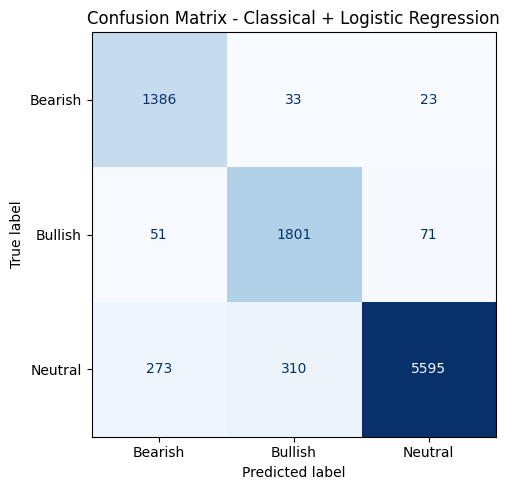

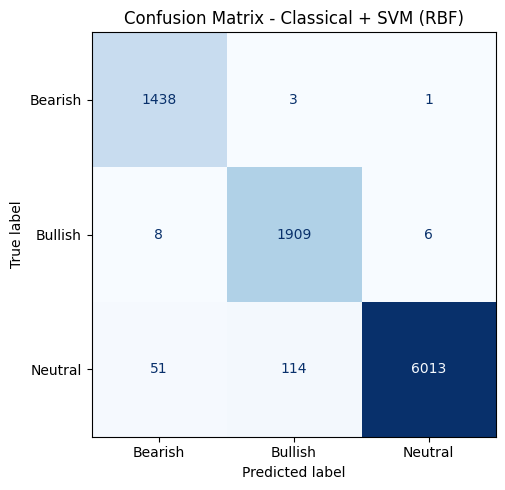

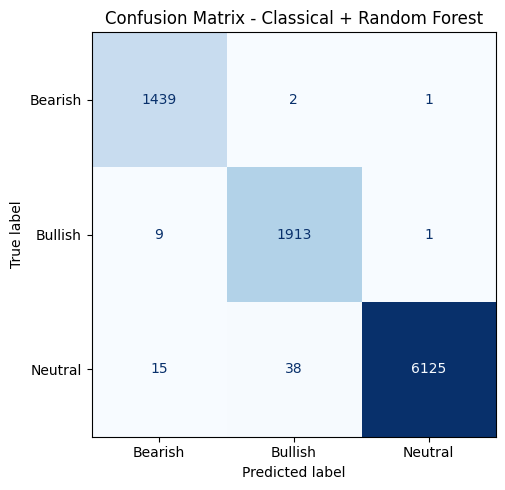


Transformer model confusion matrices (CV-based):


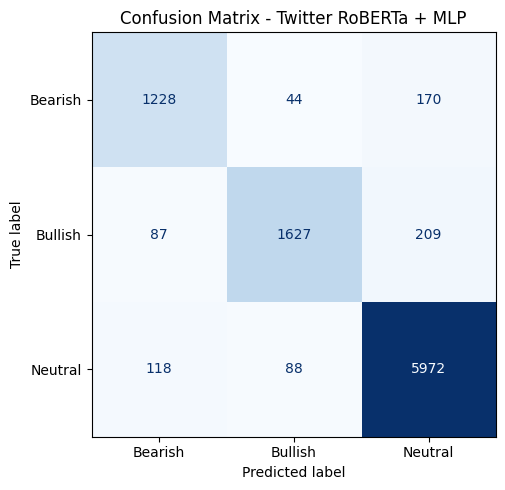

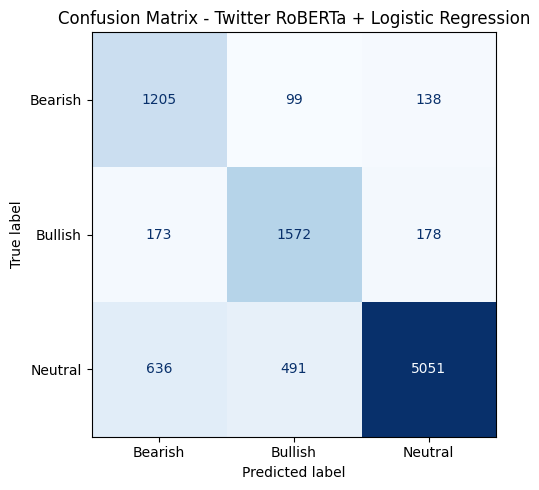

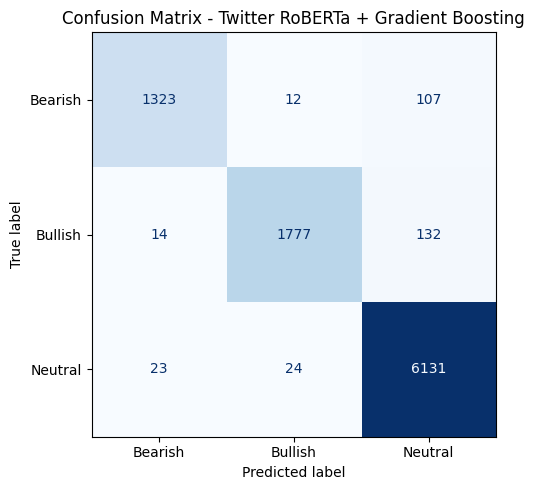

In [21]:
print("Classical model confusion matrices (CV-based):")
for experiment_name in classical_results_df["model"].head(3):
    plot_model_confusion_matrix(
        y_labels,
        classical_runs[experiment_name]["predictions"],
        model_name=experiment_name,
    )

print("\nTransformer model confusion matrices (CV-based):")
for experiment_name in transformer_results_df["model"].head(3):
    plot_model_confusion_matrix(
        y_labels,
        transformer_runs[experiment_name]["predictions"],
        model_name=experiment_name,
    )

Model Comparison (5-Fold CV Results):


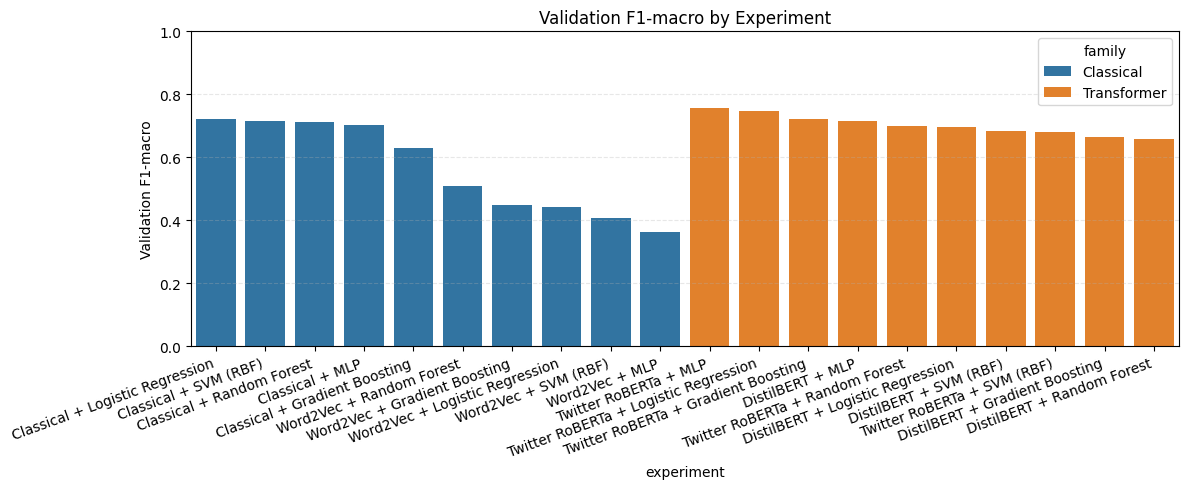

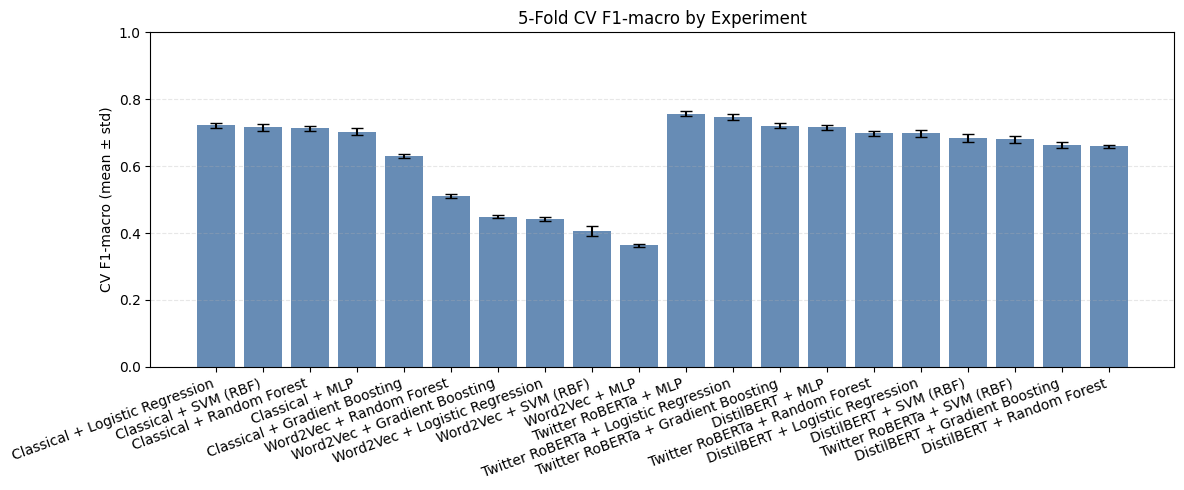

,Family,Experiment,Accuracy,Precision,Recall,Val F1,CV F1 Mean,CV F1 Std,CV Accuracy Mean,CV Accuracy Std
0,Classical,Classical + Logistic Regression,0.7908,0.7151,0.7307,0.7224,0.7224,0.0080,0.7908,0.0066
1,Classical,Classical + SVM (RBF),0.8043,0.7620,0.6867,0.7156,0.7156,0.0113,0.8043,0.0073
2,Classical,Classical + Random Forest,0.7877,0.7171,0.7107,0.7131,0.7131,0.0073,0.7877,0.0050
3,Classical,Classical + MLP,0.7933,0.7415,0.6781,0.7030,0.7030,0.0099,0.7933,0.0069
4,Classical,Classical + Gradient Boosting,0.7658,0.7860,0.5826,0.6308,0.6308,0.0070,0.7658,0.0034
5,Classical,Word2Vec + Random Forest,0.6677,0.5276,0.5026,0.5105,0.5105,0.0068,0.6677,0.0088
6,Classical,Word2Vec + Gradient Boosting,0.6845,0.5605,0.4428,0.4486,0.4486,0.0048,0.6845,0.0034
7,Classical,Word2Vec + Logistic Regression,0.5437,0.4410,0.4572,0.4425,0.4425,0.0059,0.5437,0.0038
8,Classical,Word2Vec + SVM (RBF),0.4608,0.4250,0.4409,0.4062,0.4062,0.0137,0.4608,0.0208
9,Classical,Word2Vec + MLP,0.6677,0.6458,0.3878,0.3635,0.3635,0.0046,0.6677,0.0025


In [22]:
comparison_df = pd.concat(
    [
        build_model_comparison_df(classical_runs, family="Classical"),
        build_model_comparison_df(transformer_runs, family="Transformer"),
    ],
    ignore_index=True,
)

# Display comparison with CV metrics prioritized
print("Model Comparison (5-Fold CV Results):")
print("=" * 80)
plot_family_validation_f1(comparison_df)
plot_family_cv_f1(comparison_df)
style_model_comparison_table(comparison_df)

### Fine-tuning Twitter RoBERTa + Classifier on Top

This section focuses only on **Twitter RoBERTa**.

Configuration:
- fine-tune for **3 epochs**
- evaluate the same classifier family on top of the fine-tuned encoder embeddings (fold-by-fold CV)

This gives a direct comparison against the frozen Twitter RoBERTa encoder + classifier baselines from the previous section.

In [23]:
FINE_TUNE_EPOCHS = 3
roberta_name = "Twitter RoBERTa"
roberta_checkpoint = TRANSFORMER_ENCODERS[roberta_name]

print(f"\nFine-tuning {roberta_name} for {FINE_TUNE_EPOCHS} epochs...")
run = run_finetune_encoder_cv_experiment(
    model_name=roberta_name,
    checkpoint=roberta_checkpoint,
    X_text=X_transformer,
    y=y_labels,
    cv=cv_splitter,
    classifiers=CLASSIFIERS,
    max_length=MAX_LENGTH,
    num_train_epochs=FINE_TUNE_EPOCHS,
)

ft_results_df = run["classifier_results"].copy()
ft_results_df["fine_tune_epochs"] = FINE_TUNE_EPOCHS
ft_results_df["setup"] = "Fine-tuned encoder + classifier"
ft_results_df = ft_results_df.sort_values(
    "cv_f1_macro_mean", ascending=False
).reset_index(drop=True)

baseline_rows = []
if "transformer_results_df" in globals() and not transformer_results_df.empty:
    for clf_name in CLASSIFIERS.keys():
        baseline_name = f"{roberta_name} + {clf_name}"
        hit = transformer_results_df[transformer_results_df["model"] == baseline_name]
        if not hit.empty:
            m = hit.iloc[0]
            baseline_rows.append(
                {
                    "model": baseline_name,
                    "setup": "Frozen encoder + classifier",
                    "fine_tune_epochs": 0,
                    "cv_precision_mean": m.get("cv_precision_macro_mean", m.get("precision")),
                    "cv_recall_mean": m.get("cv_recall_macro_mean", m.get("recall")),
                    "cv_f1_macro_mean": m.get("cv_f1_macro_mean"),
                    "cv_accuracy_mean": m.get("cv_accuracy_mean", m.get("accuracy")),
                }
            )

compare_df = pd.concat(
    [pd.DataFrame(baseline_rows), ft_results_df],
    ignore_index=True,
    sort=False,
)

print("\nTwitter RoBERTa: frozen vs fine-tuned + classifier")
display(
    compare_df[[
        "model",
        "setup",
        "fine_tune_epochs",
        "cv_precision_mean",
        "cv_recall_mean",
        "cv_f1_macro_mean",
        "cv_accuracy_mean",
    ]]
    .sort_values(["cv_f1_macro_mean", "model"], ascending=[False, True])
    .style.format(
        {
            "cv_precision_mean": "{:.4f}",
            "cv_recall_mean": "{:.4f}",
            "cv_f1_macro_mean": "{:.4f}",
            "cv_accuracy_mean": "{:.4f}",
        },
        na_rep="-",
    )
)


Fine-tuning Twitter RoBERTa for 3 epochs...
  Fold 1/5...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'eval_loss': '0.3887', 'eval_runtime': '1.494', 'eval_samples_per_second': '1278', 'eval_steps_per_second': '80.31', 'epoch': '1'}
{'eval_loss': '0.5492', 'eval_runtime': '1.481', 'eval_samples_per_second': '1289', 'eval_steps_per_second': '81.01', 'epoch': '2'}
{'eval_loss': '0.6072', 'eval_runtime': '1.481', 'eval_samples_per_second': '1289', 'eval_steps_per_second': '81.04', 'epoch': '3'}
{'train_runtime': '148.6', 'train_samples_per_second': '154.1', 'train_steps_per_second': '19.27', 'train_loss': '0.3233', 'epoch': '3'}


Twitter RoBERTa FT fold 1 train emb:   0%|          | 0/478 [00:00<?, ?it/s]

Twitter RoBERTa FT fold 1 val emb:   0%|          | 0/120 [00:00<?, ?it/s]

...

{'eval_loss': '0.3926', 'eval_runtime': '1.482', 'eval_samples_per_second': '1287', 'eval_steps_per_second': '80.97', 'epoch': '1'}
{'eval_loss': '0.4421', 'eval_runtime': '1.49', 'eval_samples_per_second': '1281', 'eval_steps_per_second': '80.56', 'epoch': '2'}
{'eval_loss': '0.5118', 'eval_runtime': '1.482', 'eval_samples_per_second': '1288', 'eval_steps_per_second': '80.99', 'epoch': '3'}
{'train_runtime': '149', 'train_samples_per_second': '153.7', 'train_steps_per_second': '19.22', 'train_loss': '0.326', 'epoch': '3'}


Twitter RoBERTa FT fold 5 train emb:   0%|          | 0/478 [00:00<?, ?it/s]

Twitter RoBERTa FT fold 5 val emb:   0%|          | 0/120 [00:00<?, ?it/s]

    Logistic Regression | Precision: 0.8679 | Recall: 0.8617 | F1: 0.8648 | Accuracy: 0.8957
    Random Forest | Precision: 0.8686 | Recall: 0.8758 | F1: 0.8720 | Accuracy: 0.8988
    SVM (RBF) | Precision: 0.8638 | Recall: 0.8817 | F1: 0.8723 | Accuracy: 0.8994
    Gradient Boosting | Precision: 0.8711 | Recall: 0.8649 | F1: 0.8679 | Accuracy: 0.8973
    MLP | Precision: 0.8807 | Recall: 0.8670 | F1: 0.8734 | Accuracy: 0.9009

Twitter RoBERTa: frozen vs fine-tuned + classifier


,model,setup,fine_tune_epochs,cv_precision_mean,cv_recall_mean,cv_f1_macro_mean,cv_accuracy_mean
5,Twitter RoBERTa FT + Random Forest,Fine-tuned encoder + classifier,3,0.8611,0.8676,0.8641,0.8933
6,Twitter RoBERTa FT + MLP,Fine-tuned encoder + classifier,3,0.8725,0.8562,0.8635,0.8937
7,Twitter RoBERTa FT + SVM (RBF),Fine-tuned encoder + classifier,3,0.8512,0.8706,0.8604,0.8898
8,Twitter RoBERTa FT + Gradient Boosting,Fine-tuned encoder + classifier,3,0.8659,0.8532,0.8590,0.8902
9,Twitter RoBERTa FT + Logistic Regression,Fine-tuned encoder + classifier,3,0.8586,0.8552,0.8567,0.8884
4,Twitter RoBERTa + MLP,Frozen encoder + classifier,0,0.7809,0.7427,0.7570,0.8256
0,Twitter RoBERTa + Logistic Regression,Frozen encoder + classifier,0,0.7247,0.7866,0.7472,0.7936
3,Twitter RoBERTa + Gradient Boosting,Frozen encoder + classifier,0,0.7758,0.6884,0.7212,0.8111
1,Twitter RoBERTa + Random Forest,Frozen encoder + classifier,0,0.7453,0.6724,0.6983,0.7984
2,Twitter RoBERTa + SVM (RBF),Frozen encoder + classifier,0,0.6729,0.6907,0.6804,0.7593


# Decoder-only Model

This section evaluates one larger open-source decoder-only model as a zero-shot baseline under the same stratified CV protocol.

In [24]:
# Zero-shot decoder-only sentiment classification with unified stratified CV
DECODER_MODEL_NAME = "TinyLlama-1.1B-Chat"
DECODER_CHECKPOINT = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print(f"Evaluating decoder model: {DECODER_MODEL_NAME} ({DECODER_CHECKPOINT})")
decoder_run = run_decoder_cv_experiment(
    model_name=DECODER_MODEL_NAME,
    checkpoint=DECODER_CHECKPOINT,
    X_text=X_transformer,
    y=y_labels,
    cv=cv_splitter,
    label_map=LABEL_MAP,
    batch_size=16,
)

decoder_results_df = pd.DataFrame([
    {
        "model": decoder_run["model"],
        "checkpoint": decoder_run["checkpoint"],
        "cv_precision_mean": decoder_run["cv_precision_mean"],
        "cv_precision_std": decoder_run["cv_precision_std"],
        "cv_recall_mean": decoder_run["cv_recall_mean"],
        "cv_recall_std": decoder_run["cv_recall_std"],
        "cv_f1_macro_mean": decoder_run["cv_f1_macro_mean"],
        "cv_f1_macro_std": decoder_run["cv_f1_macro_std"],
        "cv_accuracy_mean": decoder_run["cv_accuracy_mean"],
        "cv_accuracy_std": decoder_run["cv_accuracy_std"],
    }
])

print("\nDecoder-only model CV results (zero-shot):")
display(
    decoder_results_df.style.format(
        {
            "cv_precision_mean": "{:.4f}",
            "cv_precision_std": "{:.4f}",
            "cv_recall_mean": "{:.4f}",
            "cv_recall_std": "{:.4f}",
            "cv_f1_macro_mean": "{:.4f}",
            "cv_f1_macro_std": "{:.4f}",
            "cv_accuracy_mean": "{:.4f}",
            "cv_accuracy_std": "{:.4f}",
        }
)
)

Evaluating decoder model: TinyLlama-1.1B-Chat (TinyLlama/TinyLlama-1.1B-Chat-v1.0)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Fold 1/5 | Precision: 0.4029 | Recall: 0.4207 | F1: 0.3739 | Accuracy: 0.4117
  Fold 2/5 | Precision: 0.3882 | Recall: 0.4009 | F1: 0.3634 | Accuracy: 0.4096
  Fold 3/5 | Precision: 0.3828 | Recall: 0.3988 | F1: 0.3556 | Accuracy: 0.3960
  Fold 4/5 | Precision: 0.4082 | Recall: 0.4297 | F1: 0.3789 | Accuracy: 0.4167
  Fold 5/5 | Precision: 0.4098 | Recall: 0.4327 | F1: 0.3812 | Accuracy: 0.4203

Decoder-only model CV results (zero-shot):


,model,checkpoint,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_macro_mean,cv_f1_macro_std,cv_accuracy_mean,cv_accuracy_std
0,TinyLlama-1.1B-Chat,TinyLlama/TinyLlama-1.1B-Chat-v1.0,0.3984,0.0109,0.4166,0.0142,0.3706,0.0097,0.4109,0.0083
